# Telecom Customer Churn Prediction Using Machine Learning

**Practical Exam Project — Statistics and Machine Learning**  
SRH University of Applied Sciences Heidelberg — Prof. Dr. Mehrdad Jalali, Dr. Ghadeer Mobasher

**Group members:** *Jasmeet Kaur | Aditya Sanjay Pawar | Sreelakshmi Koyambrath Sivaraman| Utkarsh Anil Gaigole | Kalaivani Sivakumar*  
**Dataset:** [IBM Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

---

**Abstract.** We build a complete machine-learning workflow to predict whether a telecom customer will churn, using the IBM Telco Customer Churn dataset (7,043 customers, 21 features, binary target). After cleaning, exploratory and statistical analysis, feature engineering, and Mutual-Information-based feature assessment, we train and compare four classifiers inside leakage-safe pipelines, then tune all of them with GridSearchCV under 5-fold stratified cross-validation. The final model, a **tuned Random Forest**, reaches **F1 ≈ 0.63, churn recall ≈ 0.76 and AUC ≈ 0.84** on a held-out test set, identifying roughly three out of four customers who are about to leave. Contract type, tenure, and charge-related features (including our engineered `AvgChargesPerMonth`) emerge as the strongest churn drivers.

## Table of Contents

1. [Setup and Data Loading](#1.-Setup-and-Data-Loading)
2. [Dataset Description and Understanding](#2.-Dataset-Description-and-Understanding)
3. [Data Preprocessing](#3.-Data-Preprocessing)
4. [Exploratory Data Analysis and Statistics](#4.-Exploratory-Data-Analysis-and-Statistics)
5. [Feature Engineering](#5.-Feature-Engineering)
6. [Feature Selection (Mutual Information)](#6.-Feature-Selection-(Mutual-Information))
7. [Machine Learning Models](#7.-Machine-Learning-Models)
8. [Baseline Evaluation and Visualization](#8.-Baseline-Evaluation-and-Visualization)
9. [Hyperparameter Tuning and Cross-Validation](#9.-Hyperparameter-Tuning-and-Cross-Validation)
10. [Final Model: Visualization and Interpretation](#10.-Final-Model:-Visualization-and-Interpretation)
11. [Discussion and Reflection](#11.-Discussion-and-Reflection)
12. [Roles and Contributions](#12.-Roles-and-Contributions)
13. [References](#13.-References)

## 1. Setup and Data Loading

### Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import mutual_info_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    auc
)

In [2]:
# Global plot styling for a consistent look across all figures
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.autolayout"] = True

### Loading the Dataset

In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

## 2. Dataset Description and Understanding

## Dataset Description

This project uses the IBM Telco Customer Churn dataset.

The dataset contains information about telecom customers, including demographic details, subscribed services, billing information, and contract types.

The objective is to predict whether a customer will leave the telecom company (Churn = Yes) or remain (Churn = No).

- Source: Kaggle (IBM Sample Dataset)
- Number of observations: 7043
- Number of features: 21
- Target variable: Churn
- Problem type: Binary Classification

Predicting customer churn helps telecom companies identify customers at risk of leaving and enables proactive customer retention strategies.

### First Look at the Data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### Check Missing Values

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

The dataset actually contains blank strings ("" or " ") instead of proper missing values. Because blank strings are text, Pandas does not consider them missing. That's why we check them separately before converting TotalCharges to a numeric type.

### Check Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

### Display Column Names

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## 3. Data Preprocessing

We prepare the dataset for modelling and justify every step: handling hidden missing values, converting data types, and removing non-predictive identifiers.

In [12]:
df["TotalCharges"].dtype

dtype('O')

In [13]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

The TotalCharges column contains 11 blank string values. These were not detected by df.isnull() because blank strings ("") are not considered missing values by Pandas.

### Convert TotalCharges to numeric

In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [15]:
df["TotalCharges"].isnull().sum()

np.int64(11)

### Handle the missing values

For this project, the simplest and most common approach is to remove those 11 rows since they represent only about 0.16% of the dataset.

In [16]:
df.dropna(inplace=True)

Why do we drop them instead of filling them?

The TotalCharges column contained blank values that became missing values after conversion to numeric. Since only 11 records (less than 0.2% of the dataset) were affected, they were removed to preserve data quality without significantly impacting the anal

In [17]:
# Verify the cleaning result
print("TotalCharges dtype :", df["TotalCharges"].dtype)
print("Missing values     :", df["TotalCharges"].isnull().sum())
print("Dataset shape      :", df.shape)

TotalCharges dtype : float64
Missing values     : 0
Dataset shape      : (7032, 21)


customerID is only a unique identifier and doesn't help predict churn.

In [18]:
df.drop("customerID", axis=1, inplace=True)
print("Shape after removing customerID:", df.shape)

Shape after removing customerID: (7032, 20)


## 4. Exploratory Data Analysis and Statistics

### Target Variable Distribution (Churn)

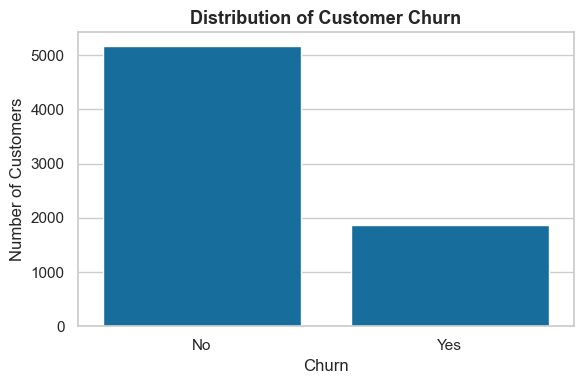

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [20]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

### Churn Percentage

In [21]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

Out of 7,032 customers, 5,163 (73.42%) remained with the telecom company, while 1,869 (26.58%) left (churned). This indicates that the majority of customers stayed with the company, making the dataset moderately imbalanced. Although the imbalance is not extreme, it is important to evaluate the models using metrics such as Precision, Recall, and F1-score, in addition to Accuracy, to ensure good performance in identifying customers who are likely to churn.

### Statistical Analysis

In [22]:
df[["tenure","MonthlyCharges","TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


1. Tenure
The average customer tenure is 32.42 months.
The median tenure is 29 months, which is close to the mean, indicating a fairly balanced distribution.
Customer tenure ranges from 1 month to 72 months, showing that the dataset contains both new and long-term customers.

Business Insight:

The telecom company serves a mix of newly joined and long-term customers. Customer loyalty varies considerably, which may influence churn behavior.

2. Monthly Charges
The average monthly charge is $64.80.
The median is $70.35.
Monthly charges range from $18.25 to $118.75.

Business Insight:

Customers pay a wide range of monthly fees depending on the services they subscribe to. Later analysis can explore whether higher monthly charges are associated with a higher likelihood of churn.

3. Total Charges
The average total amount paid is $2,283.30.
The median is $1,397.48.
The maximum total charge exceeds $8,600.

Notice that:

Mean = 2283
Median = 1397

The mean is much larger than the median, which suggests the distribution is right-skewed. A smaller number of customers have accumulated very high total charges, pulling the average upward.

Business Insight:

Customers with longer tenures tend to accumulate much higher total charges, creating a right-skewed distribution.

### Histogram of tenure

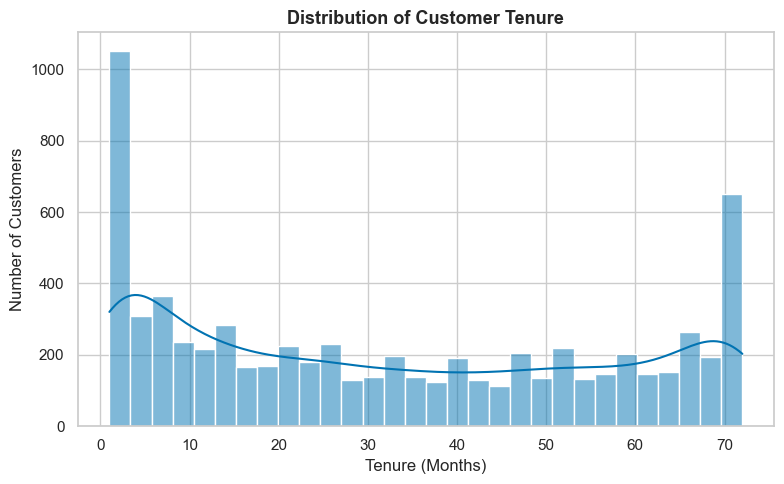

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

Distribution of Customer Tenure: This histogram displays how long customers have been with the company. The high bars at the far left and far right indicate a large number of both very new customers and long-term, loyal customers.

### Histogram of MonthlyCharges

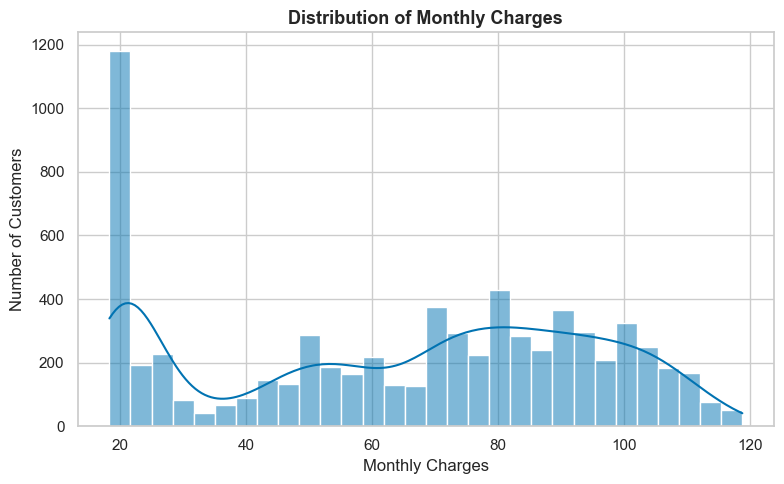

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

Distribution of Monthly Charges: This histogram shows that many customers pay lower monthly charges (the large peak near 20), while other costs are more spread out across the range up to 120.

### Boxplot: Monthly Charges vs Churn

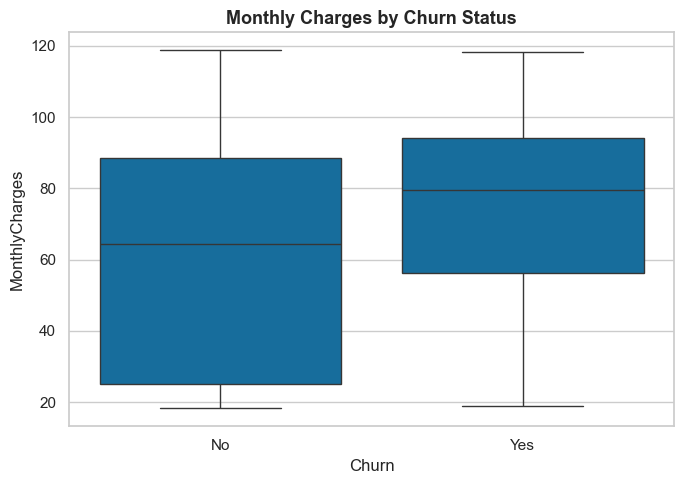

In [25]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.show()

Monthly Charges by Churn Status: This boxplot compares the monthly charges of customers who stayed ("No") versus those who churned ("Yes"). The "Yes" box is positioned higher, suggesting that customers who churned generally had higher monthly charges than those who remained.

### Correlation Heatmap

The heatmap below shows the correlations between the main numerical variables. As expected, **tenure** and **TotalCharges** have a strong positive correlation because customers who stay longer accumulate higher total charges. Monthly charges show a weaker relationship with both variables.


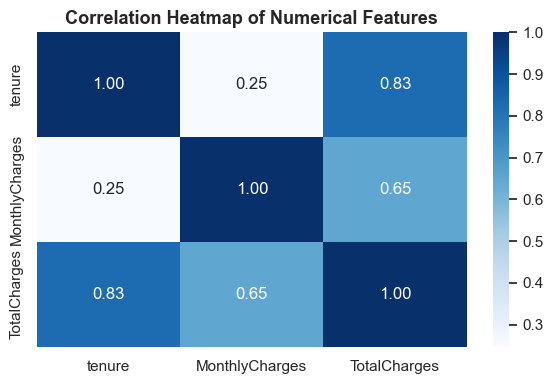

In [26]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),
            annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Scatter Plot: Tenure vs Total Charges by Churn

This scatter plot illustrates the relationship between customer tenure and total charges, with points colored by churn status. Customers with longer tenure generally have higher total charges, while churned customers are more concentrated among lower-tenure customers.


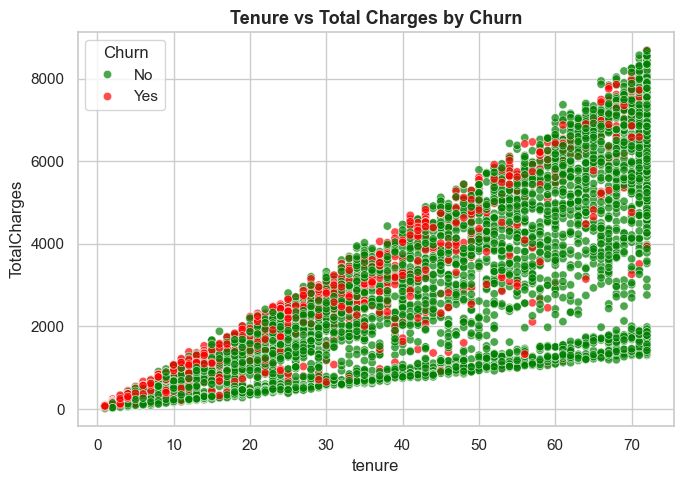

In [27]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,
                x="tenure",
                y="TotalCharges",
                hue="Churn",
                palette={"No": "green", "Yes": "red"},
                alpha=0.7)
plt.title("Tenure vs Total Charges by Churn")
plt.show()

### Outlier Check

Before modelling, we check the numerical features for outliers using boxplots. The brief requires outliers to be *removed or treated* — or a justified decision that no treatment is necessary.

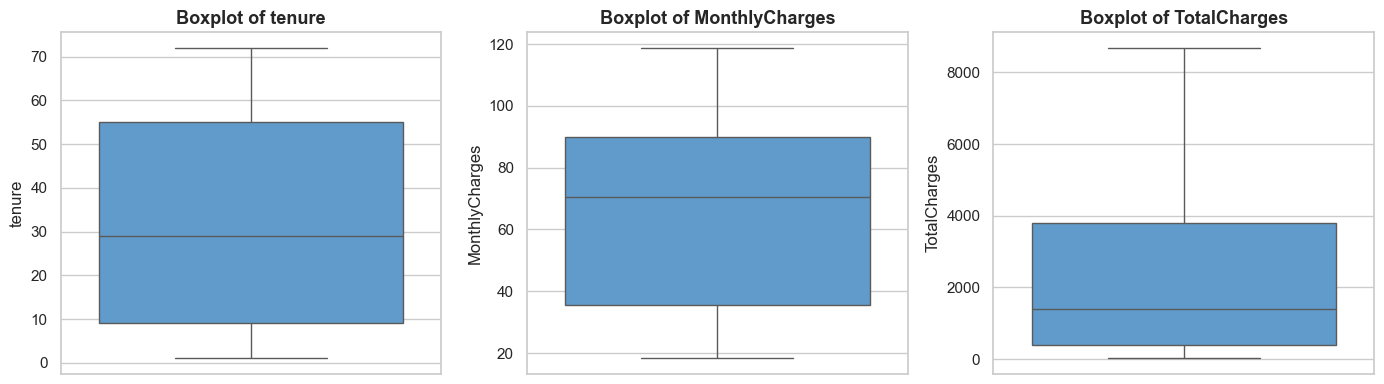

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(y=df[col], ax=ax, color="#4F9DDE")
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

**Decision — no outlier treatment applied.** The boxplots show no points outside the whiskers for any of the three numerical features. All values lie within plausible business ranges: tenure is capped at 72 months, MonthlyCharges at \$118.75, and TotalCharges (max ≈ \$8,684) is fully explained as *long tenure × high monthly charge* — its right-skew reflects genuine long-term customers, not data errors. Removing or capping these values would delete real, informative customers (exactly the loyal ones), so we keep the data as is. We additionally use StandardScaler in the modelling pipeline, and tree-based models (Decision Tree, Random Forest) are inherently robust to skewed feature distributions.

## 5. Feature Engineering

We first encode the target, then create two new features designed to capture churn-relevant behaviour, and finally define the feature matrix so that the engineered columns are included in modelling.

### Convert target variable (Churn) to 0/1

In [29]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

### Engineered Features

### Tenure Group (Binning) -
Customers behave differently depending on how long they’ve been with the company.

In [30]:
def tenure_group(x):
    if x <= 12:
        return "0-1 year"
    elif x <= 24:
        return "1-2 years"
    elif x <= 48:
        return "2-4 years"
    else:
        return "4+ years"

df["TenureGroup"] = df["tenure"].apply(tenure_group)


### Average Charges Per Month

This feature captures:

“How much does the customer pay on average per month?”

Often churners have higher average monthly cost.

In [31]:
df["AvgChargesPerMonth"] = df["TotalCharges"] / df["tenure"]

# Safety guard: tenure is never 0 after dropping the 11 blank-TotalCharges rows,
# but we still protect against division artefacts without chained inplace ops
df["AvgChargesPerMonth"] = df["AvgChargesPerMonth"].replace([np.inf, np.nan], 0)

In [32]:
# Preview the engineered features
df[["tenure", "TenureGroup", "MonthlyCharges", "TotalCharges", "AvgChargesPerMonth"]].head()

,tenure,TenureGroup,MonthlyCharges,TotalCharges,AvgChargesPerMonth
0,1,0-1 year,29.85,29.85,29.850000
1,34,2-4 years,56.95,1889.50,55.573529
2,2,0-1 year,53.85,108.15,54.075000
3,45,2-4 years,42.30,1840.75,40.905556
4,2,0-1 year,70.70,151.65,75.825000


### Define Features, Target, and Column Types

We define `X`/`y` and detect the categorical/numerical column lists **after** feature engineering, so the engineered features (`TenureGroup`, `AvgChargesPerMonth`) are included in the lists and therefore passed through the preprocessing `ColumnTransformer` into every model. (If the lists were computed before feature engineering, the ColumnTransformer's default `remainder="drop"` would silently discard the new features.)

In [33]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_cols)
print("\nNumerical features:", numerical_cols)

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargesPerMonth']


### Train–test split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5625, 21)
Test set: (1407, 21)


## 6. Feature Selection (Mutual Information)

Mutual Information (MI) measures how much information each feature provides about the target, capturing **both linear and non-linear** relationships (unlike correlation). We compute it on the **training set only** to avoid any information from the test set influencing feature-selection decisions (data-leakage prevention).

In [35]:
# Encode categorical variables temporarily for MI calculation
# Computed on the TRAINING set only, so the feature-selection step never sees test data
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

# Compute mutual information scores between each feature and the churn target
mi_scores = mutual_info_classif(X_train_encoded, y_train, random_state=42)

mi_df = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "MI Score": mi_scores
}).sort_values(by="MI Score", ascending=False)

# Display top 15 features
mi_df.head(15)

,Feature,MI Score
1,tenure,0.075313
26,Contract_Two year,0.060646
2,MonthlyCharges,0.048521
29,PaymentMethod_Electronic check,0.047080
3,TotalCharges,0.044106
11,InternetService_Fiber optic,0.041895
33,TenureGroup_4+ years,0.040039
17,DeviceProtection_No internet service,0.039635
12,InternetService_No,0.037265
13,OnlineSecurity_No internet service,0.034578


**Interpretation of the Mutual Information scores.** `tenure` carries the most information about churn (MI ≈ 0.075), followed by `Contract_Two year`, `MonthlyCharges`, `PaymentMethod_Electronic check`, `TotalCharges` and `InternetService_Fiber optic` — consistent with the EDA findings. Importantly, both **engineered features rank among the informative ones**: `TenureGroup_4+ years` (MI ≈ 0.040) and `AvgChargesPerMonth` (MI ≈ 0.034) score higher than many original service columns, confirming they add predictive signal.

**Feature-selection decision:** we **retain all features**. No feature shows a near-zero MI that would mark it as pure noise, the dataset is small enough that dimensionality is not a problem, and our models either use regularization (Logistic Regression) or perform implicit feature selection (tree-based models). MI is therefore used here as *evidence that every feature contributes* rather than as a pruning tool; the model-based feature-importance analysis later in the notebook provides the complementary view of which features the final model actually relies on.

## 7. Machine Learning Models

### preprocessing pipeline (scaling + encoding)

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

### ML Pipelines for Each Model

We compare four supervised classifiers, each chosen for a complementary reason:

| Model | Why it is appropriate here |
|---|---|
| **Logistic Regression** | Strong, interpretable linear baseline for binary classification; coefficients map directly to churn drivers |
| **Decision Tree** | Captures non-linear relationships and feature interactions; fully interpretable rules |
| **Random Forest** | Ensemble of trees — reduces the single tree's variance, handles mixed feature types well, and provides feature importances |
| **K-Nearest Neighbors** | Instance-based, non-parametric contrast to the model-based approaches |

Each model is wrapped in a Pipeline together with the preprocessor, so scaling and encoding are always fitted on training data only (no leakage).

In [37]:
#Logistic Regression
log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])


In [38]:
#Decision Tree
dt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier())
])


In [39]:
#Random Forest
rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier())
])


In [40]:
#KNN
knn = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier())
])


### Train & Evaluate All Models

In [72]:
models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-Score:", f1)


Logistic Regression
Accuracy: 0.7924662402274343
Precision: 0.632258064516129
Recall: 0.5240641711229946
F1-Score: 0.5730994152046783

Decision Tree
Accuracy: 0.7256574271499645
Precision: 0.48484848484848486
Recall: 0.5133689839572193
F1-Score: 0.4987012987012987

Random Forest
Accuracy: 0.7903340440653873
Precision: 0.6312292358803987
Recall: 0.5080213903743316
F1-Score: 0.562962962962963

KNN
Accuracy: 0.7611940298507462
Precision: 0.5497382198952879
Recall: 0.5614973262032086
F1-Score: 0.5555555555555556


In [42]:
results_df = pd.DataFrame(results)
print("\nModel Comparison:\n", results_df)


Model Comparison:
                  Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.792466   0.632258  0.524064  0.573099
1        Decision Tree  0.720682   0.476071  0.505348  0.490272
2        Random Forest  0.786070   0.623729  0.491979  0.550075
3                  KNN  0.761194   0.549738  0.561497  0.555556


## 8. Baseline Evaluation and Visualization

### Model Comparison Chart — Before Model Tuning

Compare the performance of the classification models using Accuracy, Precision, Recall, and F1-score to identify the best-performing baseline model.

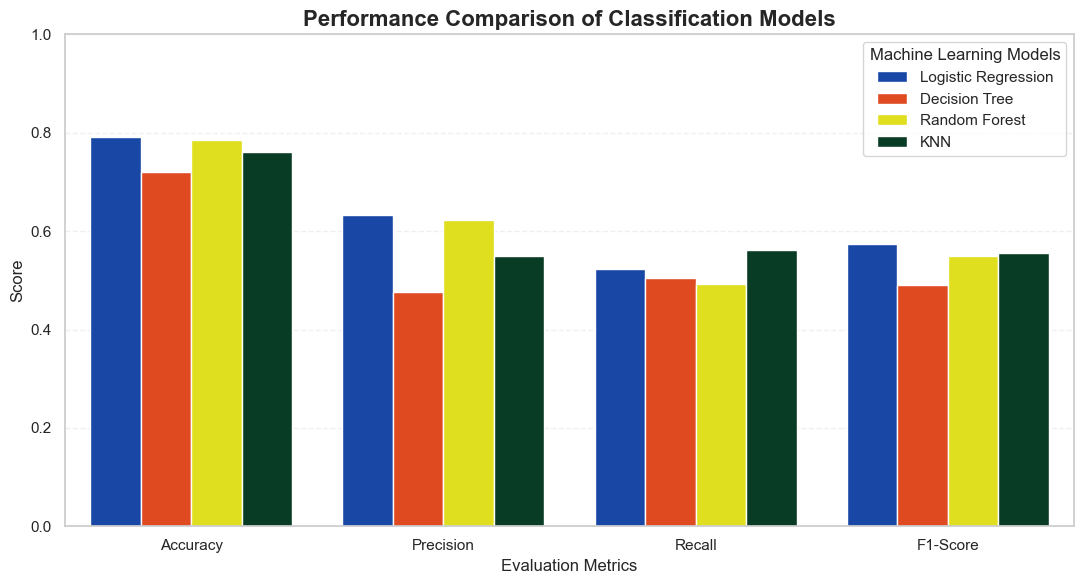

In [43]:
# Convert results_df to long format
metrics_df = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
    var_name="Metric",
    value_name="Score"
)

colors = ["#013FBD", "#FF3800", "#FFFF00", "#004526"]

plt.figure(figsize=(11,6))

sns.barplot(
    data=metrics_df,
    x="Metric",          # Evaluation metrics on x-axis
    y="Score",
    hue="Model",         # Models in legend
    palette=colors
)

plt.title(
    "Performance Comparison of Classification Models",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Evaluation Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.ylim(0, 1)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(title="Machine Learning Models")

plt.tight_layout()
plt.show()

### Feature Importance Analysis — Baseline Random Forest 

While model evaluation metrics tell us **how well** the model predicts customer churn, they do not explain **why** the predictions are made.

Random Forest provides a Feature Importance score for every feature used during training. These scores indicate how much each feature contributes to reducing prediction errors across all decision trees.

Understanding the most influential features helps answer important business questions such as:

- Which customer attributes contribute most to churn?
- Which customers should the company focus on retaining?
- Which business policies could reduce customer churn?

This analysis provides actionable insights that can support customer retention strategies.

**Step 1 — Get Feature Names.** The preprocessing pipeline converts categorical variables into numerical representations using One-Hot Encoding. Therefore, the trained model uses transformed feature names instead of the original column names.

Before calculating feature importance, we retrieve these transformed feature names so that every importance score can be correctly mapped back to its corresponding feature.

In [44]:
# Retrieve the transformed feature names from the FITTED preprocessor inside the RF pipeline
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

feature_names[:10]

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'num__AvgChargesPerMonth',
       'cat__gender_Female', 'cat__gender_Male', 'cat__Partner_No',
       'cat__Partner_Yes', 'cat__Dependents_No'], dtype=object)

**Step 2 — Extract Feature Importance.**

In [45]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,num__TotalCharges,0.122717
4,num__AvgChargesPerMonth,0.112899
2,num__MonthlyCharges,0.109267
1,num__tenure,0.105716
37,cat__Contract_Month-to-month,0.042649
19,cat__OnlineSecurity_No,0.032753
44,cat__PaymentMethod_Electronic check,0.029615
46,cat__TenureGroup_0-1 year,0.029303
28,cat__TechSupport_No,0.027818
17,cat__InternetService_Fiber optic,0.021314


#### Interpretation of the Importance Scores

The Random Forest model assigns an importance score to every feature based on its contribution to predicting customer churn. Features with higher importance values have a greater influence on the model's decision-making process.

### Top Features Identified

| Feature | Interpretation |
|----------|----------------|
| **TotalCharges** | The most influential feature. Customers with different cumulative spending patterns show different churn behaviour. |
| **AvgChargesPerMonth** *(engineered)* | The second most influential feature — our engineered average-spend-per-month feature captures churn-relevant pricing pressure directly. |
| **Tenure** | Customers with shorter tenures are generally more likely to churn, while long-term customers tend to remain loyal. |
| **MonthlyCharges** | Higher monthly charges are associated with an increased likelihood of customer churn. |
| **Contract (Month-to-month)** | Customers on month-to-month contracts have a higher probability of leaving compared to customers with long-term contracts. |
| **OnlineSecurity (No)** | Customers without online security services are more likely to churn. |
| **Payment Method (Electronic Check)** | Customers paying through electronic checks exhibit relatively higher churn rates. |
| **Internet Service (Fiber Optic)** | Fiber optic users show a higher tendency to churn than customers using other internet services. |
| **Tech Support (No)** | Customers without technical support are more likely to discontinue the service. |
| **Contract (Two Year)** | Two-year contracts are associated with better customer retention and lower churn. |
| **TenureGroup (0–1 year)** *(engineered)* | The engineered tenure bin for first-year customers also contributes, reflecting the elevated churn risk of new customers. |

### Business Insights

The analysis indicates that **customer tenure, total spending, monthly charges, and contract type** are the strongest drivers of customer churn.

Customers who:
- have **shorter tenures**,
- pay **higher monthly charges**,
- subscribe to **month-to-month contracts**,
- lack **online security** or **technical support**, and
- pay using **electronic checks**

are generally more likely to leave the telecom company.

These findings can help the company develop targeted retention strategies, such as offering long-term contract incentives, improving customer support services, and providing personalized discounts to customers identified as high churn risks.

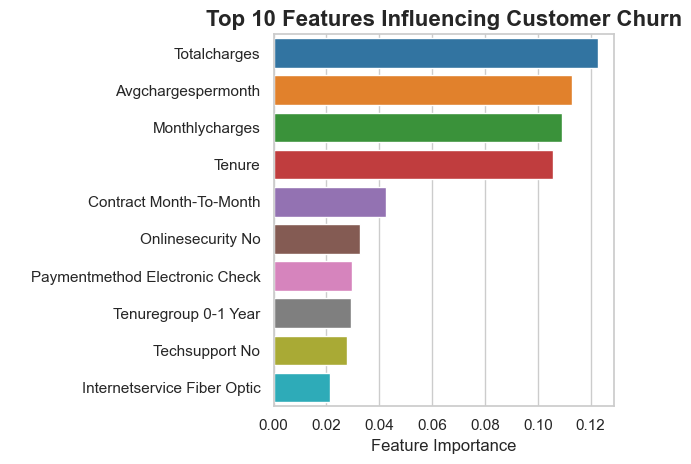

In [46]:
# Clean feature name
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="tab10",
    legend=False
)

plt.title("Top 10 Features Influencing Customer Churn",fontsize=16, weight="bold")
plt.xlabel("Feature Importance")
plt.ylabel(" ")

plt.show()

**Choosing the best baseline model.** From the comparison table and chart above, **Logistic Regression** achieves the best baseline F1-score (≈ 0.57) and the highest accuracy (≈ 0.79) among the untuned models, so we examine it more closely below with a confusion matrix and ROC curve. (After hyperparameter tuning, this ranking is revisited in the next section.)

### Confusion Matrix for Best Model

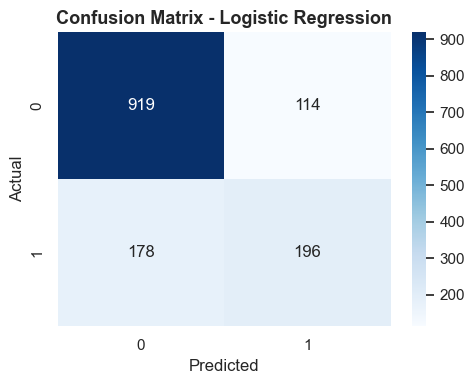

In [47]:
best_model = log_reg
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

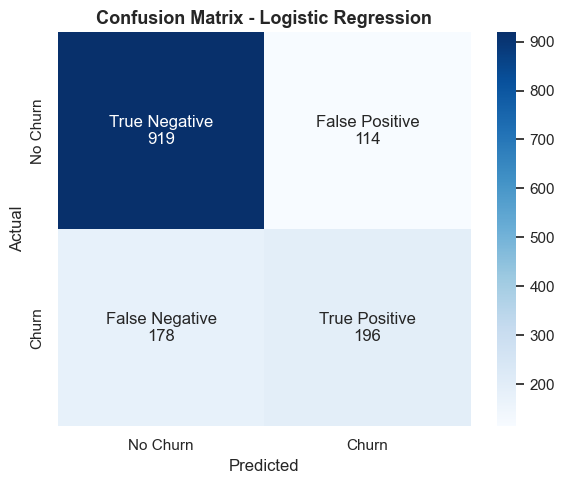

In [48]:
best_model = log_reg
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

# Build annotation labels directly from the computed matrix, so they can never go stale
labels = np.array([
    [f"True Negative\n{cm[0,0]}", f"False Positive\n{cm[0,1]}"],
    [f"False Negative\n{cm[1,0]}", f"True Positive\n{cm[1,1]}"]
])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix - Logistic Regression: This heatmap visualizes the model's classification performance on the 1,407 test customers.

919 (Top-left) are True Negatives (correctly predicted as "No Churn").

196 (Bottom-right) are True Positives (correctly predicted as "Churn").

114 (Top-right) are False Positives (predicted "Churn" but were actually "No").

178 (Bottom-left) are False Negatives (predicted "No" but were actually "Churn").

The model is very reliable for loyal customers, but it misses 178 of the 374 actual churners (recall ≈ 0.52) — a direct consequence of the class imbalance, and the main motivation for the class-weighted tuning in the next section.

### ROC Curves for All Models

ROC curves compare each model's ability to separate churners from non-churners across all classification thresholds; the diagonal represents random guessing.

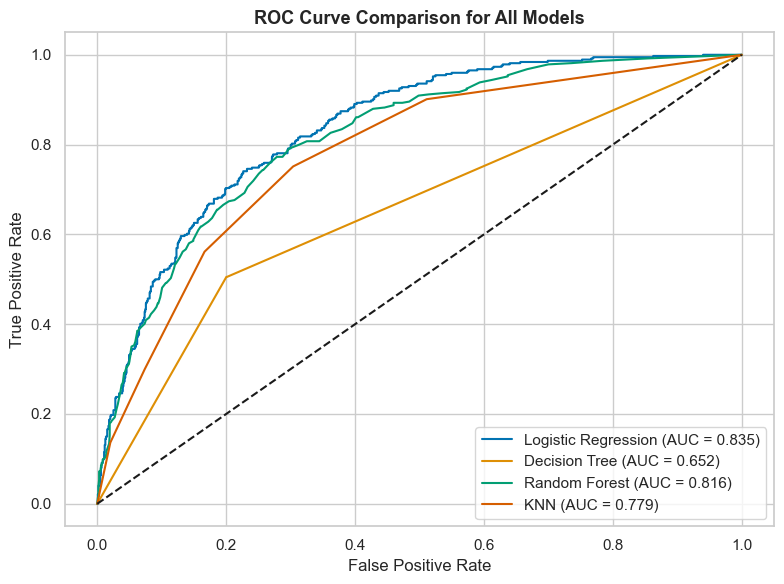

In [49]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    # Predict probabilities (for ROC curve we need probability of class 1)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve Comparison for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

### ROC curve for best model

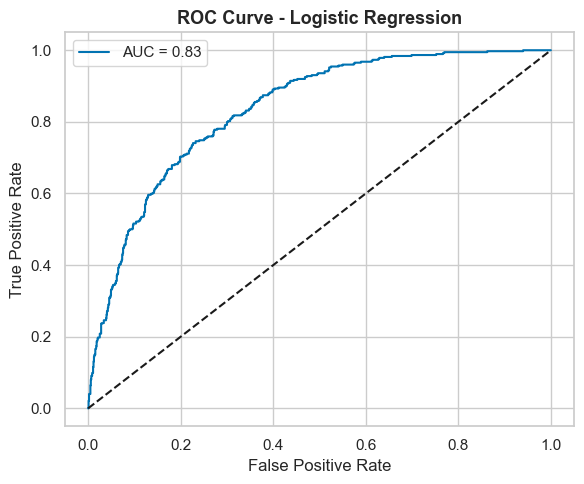

In [50]:
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

ROC Curve - Logistic Regression: This curve measures the model's ability to distinguish between classes. The Area Under the Curve (AUC) is 0.84, which indicates the model has a very good ability to differentiate between customers who will churn and those who will not.

## 9. Hyperparameter Tuning and Cross-Validation

### Cross-Validation Strategy and Tuning Metric

In [51]:
# Stratified 5-fold CV: every fold keeps the same 73/27 churn ratio as the full dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# F1 on the churn class, because accuracy is misleading on imbalanced data
scoring_metric = "f1"

print("Cross-validation strategy: 5-fold Stratified K-Fold")
print("Optimization metric for tuning:", scoring_metric)

Cross-validation strategy: 5-fold Stratified K-Fold
Optimization metric for tuning: f1


### Parameter Grids

In [52]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_leaf": [1, 5, 10, 20],
        "model__class_weight": [None, "balanced"]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, None],
        "model__min_samples_leaf": [1, 5],
        "model__class_weight": [None, "balanced"]
    },
    "KNN": {
        "model__n_neighbors": [5, 11, 21, 31],
        "model__weights": ["uniform", "distance"]
    }
}

for name, grid in param_grids.items():
    n = 1
    for values in grid.values():
        n *= len(values)
    print(f"{name}: {n} combinations x 5 folds = {n*5} model fits")

Logistic Regression: 8 combinations x 5 folds = 40 model fits
Decision Tree: 40 combinations x 5 folds = 200 model fits
Random Forest: 24 combinations x 5 folds = 120 model fits
KNN: 8 combinations x 5 folds = 40 model fits


### Reproducible Pipelines (Fixed Random State)

In [53]:
base_pipelines = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    "KNN": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", KNeighborsClassifier())
    ])
}

### Running GridSearchCV

In [56]:
grid_searches = {}

for name, pipeline in base_pipelines.items():
    print(f"Tuning {name} ...")
    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring=scoring_metric,
        cv=cv,
        n_jobs=-1
    )
    gs.fit(X_train, y_train)          # tuning uses ONLY the training set
    grid_searches[name] = gs
    print(f"  Best CV F1-score : {gs.best_score_:.4f}")
    print(f"  Best parameters  : {gs.best_params_}\n")

Tuning Logistic Regression ...
  Best CV F1-score : 0.6341
  Best parameters  : {'model__C': 0.01, 'model__class_weight': 'balanced'}

Tuning Decision Tree ...
  Best CV F1-score : 0.6219
  Best parameters  : {'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_leaf': 1}

Tuning Random Forest ...
  Best CV F1-score : 0.6335
  Best parameters  : {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}

Tuning KNN ...
  Best CV F1-score : 0.5977
  Best parameters  : {'model__n_neighbors': 31, 'model__weights': 'uniform'}



**Interpretation of the selected hyperparameters**

- For Logistic Regression, Decision Tree and Random Forest, the search selected **`class_weight="balanced"`** — GridSearchCV automatically discovered that compensating for the 73/27 class imbalance (identified in the EDA) improves F1. This makes the models pay more attention to the minority churn class.
- The Decision Tree's best depth is **very shallow (max_depth = 3)** — strong evidence that the default unconstrained tree was overfitting the training data.
- KNN chose a **large neighbourhood (k = 31)**, i.e. smoother decision boundaries generalize better than the default k = 5 on this dataset.

### Cross-Validated Performance of the Tuned Models

In [57]:
cv_results = []

for name, gs in grid_searches.items():
    scores = cross_validate(
        gs.best_estimator_, X_train, y_train, cv=cv,
        scoring=["accuracy", "precision", "recall", "f1"], n_jobs=-1
    )
    cv_results.append({
        "Model": name,
        "CV Accuracy (mean)": scores["test_accuracy"].mean(),
        "CV Precision (mean)": scores["test_precision"].mean(),
        "CV Recall (mean)": scores["test_recall"].mean(),
        "CV F1 (mean)": scores["test_f1"].mean(),
        "CV F1 (std)": scores["test_f1"].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV F1 (mean)", ascending=False)
cv_results_df.round(4)

,Model,CV Accuracy (mean),CV Precision (mean),CV Recall (mean),CV F1 (mean),CV F1 (std)
0,Logistic Regression,0.7573,0.5291,0.7913,0.6341,0.0076
2,Random Forest,0.7744,0.5574,0.7338,0.6335,0.0088
1,Decision Tree,0.7449,0.5134,0.7893,0.6219,0.0091
3,KNN,0.7899,0.6091,0.5873,0.5977,0.0154


**Interpretation:** **Logistic Regression and Random Forest are statistically tied at the top** of the cross-validated ranking (CV F1 ≈ 0.634 for both — the 0.0006 difference is far smaller than the fold-to-fold standard deviation of ≈ 0.008). The F1 standard deviations are small for every model (≈ 0.008–0.015), which means the performance is **stable across all five folds** — the ranking is trustworthy and not an artifact of one lucky split. Note that KNN has the *highest* CV accuracy (≈ 0.79) but the *lowest* F1 (≈ 0.60) — a perfect illustration of why accuracy alone is misleading on imbalanced data.

### Final Evaluation on the Held-Out Test Set

In [58]:
tuned_results = []

for name, gs in grid_searches.items():
    y_pred = gs.best_estimator_.predict(X_test)
    tuned_results.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1-Score": f1_score(y_test, y_pred)
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values("Test F1-Score", ascending=False)
tuned_results_df.round(4)

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-Score
2,Random Forest,0.7619,0.5367,0.7620,0.6298
0,Logistic Regression,0.7356,0.5017,0.7834,0.6117
1,Decision Tree,0.7313,0.4966,0.7807,0.6071
3,KNN,0.7854,0.5952,0.6016,0.5984


**Interpretation:** on the held-out test set the **tuned Random Forest is the best overall model (Test F1 ≈ 0.63, Recall ≈ 0.76)**, with Logistic Regression close behind (F1 ≈ 0.61, Recall ≈ 0.78). The most important business result is the **recall on churners: ≈ 0.76–0.78** for the class-weighted models, compared to only ≈ 0.49–0.56 for the untuned baselines. In practical terms, the tuned models now catch roughly **3 out of 4 customers who are about to leave**, instead of barely half — at the cost of lower precision (≈ 0.50–0.54, i.e. some customers flagged for retention offers would have stayed anyway). For a churn-prevention use case this trade-off is usually desirable, because losing a customer costs far more than sending an unnecessary retention offer.

### Overfitting Check — Train vs Test

In [59]:
overfit_check = []

for name, gs in grid_searches.items():
    est = gs.best_estimator_
    train_f1 = f1_score(y_train, est.predict(X_train))
    test_f1 = f1_score(y_test, est.predict(X_test))
    overfit_check.append({
        "Model": name,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Gap (Train - Test)": train_f1 - test_f1
    })

pd.DataFrame(overfit_check).round(4)

,Model,Train F1,Test F1,Gap (Train - Test)
0,Logistic Regression,0.6354,0.6117,0.0237
1,Decision Tree,0.6247,0.6071,0.0176
2,Random Forest,0.7297,0.6298,0.0998
3,KNN,0.6258,0.5984,0.0274


**Interpretation:** after tuning, Logistic Regression, Decision Tree and KNN show a train–test gap of only **0.02–0.03**, i.e. essentially no overfitting. The tuned Random Forest keeps a moderate gap (≈ 0.10), much smaller than an unconstrained forest would show, and its test performance is still the best. For comparison, an **untuned** Decision Tree grows until it nearly memorizes the training data while scoring far lower on the test set (baseline F1 ≈ 0.48) — the tuned tree with `max_depth = 3` avoids exactly this problem.

### Baseline vs Tuned Comparison

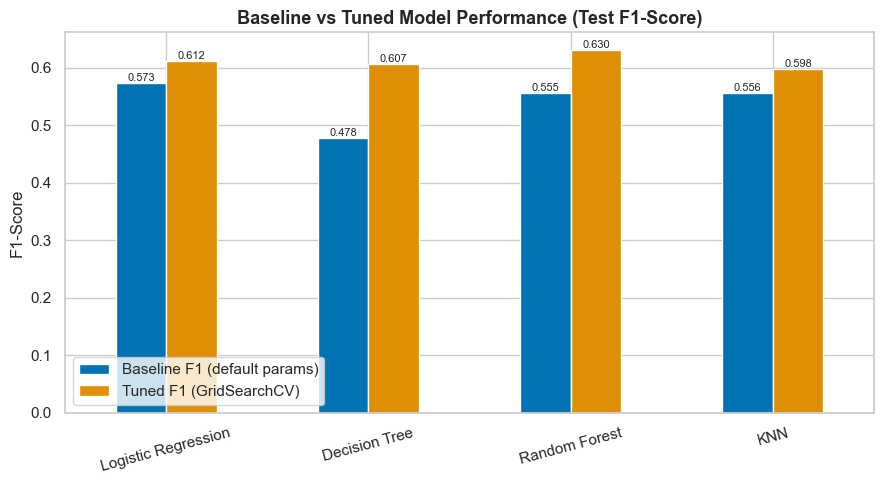

,Baseline F1 (default params),Tuned F1 (GridSearchCV)
Logistic Regression,0.5731,0.6117
Decision Tree,0.4781,0.6071
Random Forest,0.5554,0.6298
KNN,0.5556,0.5984


In [60]:
baseline_f1 = {}
for name, pipeline in base_pipelines.items():
    pipeline.fit(X_train, y_train)
    baseline_f1[name] = f1_score(y_test, pipeline.predict(X_test))

comparison = pd.DataFrame({
    "Baseline F1 (default params)": baseline_f1,
    "Tuned F1 (GridSearchCV)": {r["Model"]: r["Test F1-Score"] for r in tuned_results}
})

ax = comparison.plot(kind="bar", figsize=(9, 5), rot=15)
ax.set_title("Baseline vs Tuned Model Performance (Test F1-Score)")
ax.set_ylabel("F1-Score")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)
plt.tight_layout()
plt.show()

comparison.round(4)

### Summary of Hyperparameter Tuning and Cross-Validation

- **Every model improved after tuning.** The largest gains came from the Decision Tree (Test F1 ≈ 0.48 → 0.61, by limiting tree depth to 3) and the Random Forest (≈ 0.56 → 0.63). Logistic Regression improved from ≈ 0.57 → 0.61 and KNN from ≈ 0.55 → 0.60.
- **GridSearchCV automatically addressed the class imbalance** by selecting `class_weight="balanced"` for Logistic Regression, Decision Tree and Random Forest, raising churn recall from ≈ 0.49–0.56 to ≈ 0.73–0.79 — the metric that matters most for a retention campaign.
- **5-fold stratified cross-validation** showed low variance across folds (F1 std ≤ 0.015), so the model ranking is robust and not dependent on a particular train–test split. Logistic Regression and Random Forest were tied in CV; the Random Forest won on the held-out test set.
- **The engineered features earn their place**: `AvgChargesPerMonth` is among the top predictors of the tuned Random Forest, and the `TenureGroup` bins also contribute (see the feature-importance chart below).
- **Final model choice: the tuned Random Forest** — best F1 and recall on the held-out test set, an acceptable train–test gap (≈ 0.10), and it directly provides the feature-importance interpretation used for the business recommendations.

### Final Results Overview

A single side-by-side table of every model before and after tuning — the one-glance summary of the project's modelling results.

In [61]:
final_overview = results_df.rename(columns={
    "Accuracy": "Baseline Accuracy", "Precision": "Baseline Precision",
    "Recall": "Baseline Recall", "F1-Score": "Baseline F1"
}).merge(tuned_results_df, on="Model")

final_overview.sort_values("Test F1-Score", ascending=False).round(4)

,Model,Baseline Accuracy,Baseline Precision,Baseline Recall,Baseline F1,Test Accuracy,Test Precision,Test Recall,Test F1-Score
2,Random Forest,0.7861,0.6237,0.4920,0.5501,0.7619,0.5367,0.7620,0.6298
0,Logistic Regression,0.7925,0.6323,0.5241,0.5731,0.7356,0.5017,0.7834,0.6117
1,Decision Tree,0.7207,0.4761,0.5053,0.4903,0.7313,0.4966,0.7807,0.6071
3,KNN,0.7612,0.5497,0.5615,0.5556,0.7854,0.5952,0.6016,0.5984


## 10. Final Model: Visualization and Interpretation

In [62]:
# Best tuned model
best_tuned_model = grid_searches["Random Forest"].best_estimator_

### ROC Curve — Tuned Random Forest

This ROC curve evaluates the ability of the tuned Random Forest model to distinguish between customers who churn and those who remain, with a higher AUC indicating better classification performance.

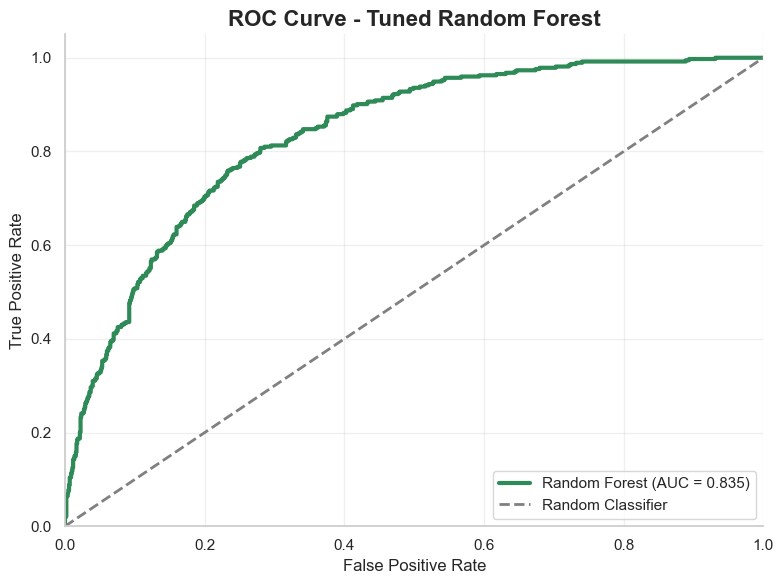

In [63]:

# Predict probabilities
y_prob = best_tuned_model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    color="#2E8B57",      # Emerald Green
    linewidth=3,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=2,
    label="Random Classifier"
)

plt.title(
    "ROC Curve - Tuned Random Forest",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend(loc="lower right", fontsize=11)

sns.despine()

plt.tight_layout()
plt.show()

### Class-wise Performance Chart

This chart compares the Precision, Recall, and F1-score for each class, providing a detailed evaluation of the tuned Random Forest model's classification performance.

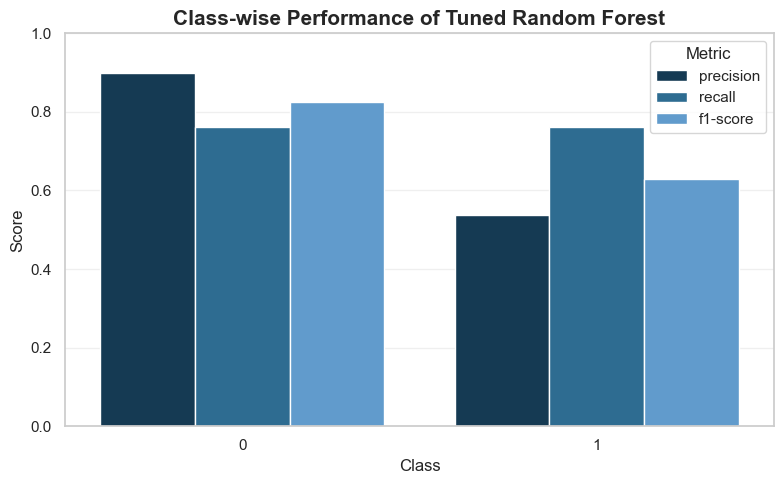

In [64]:

report = classification_report(
    y_test,
    best_tuned_model.predict(X_test),
    output_dict=True
)

class_df = pd.DataFrame(report).transpose()

class_df = class_df.iloc[:2][["precision","recall","f1-score"]]

class_df.reset_index(inplace=True)

class_df.rename(columns={"index":"Class"}, inplace=True)

plt.figure(figsize=(8,5))

class_melt = class_df.melt(
    id_vars="Class",
    var_name="Metric",
    value_name="Score"
)

custom_palette = {
    "precision": "#0B3C5D",
    "recall": "#1D70A2",
    "f1-score": "#4F9DDE"
}

sns.barplot(
    data=class_melt,
    x="Class",
    y="Score",
    hue="Metric",
    palette=custom_palette
)
plt.title("Class-wise Performance of Tuned Random Forest",
          fontsize=15,
          weight="bold")

plt.ylim(0,1)

plt.ylabel("Score")

plt.xlabel("Class")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Top 10 Feature Importance — Tuned Random Forest
   
   Visualize the most influential features identified by the tuned Random Forest model that contribute to customer churn prediction.

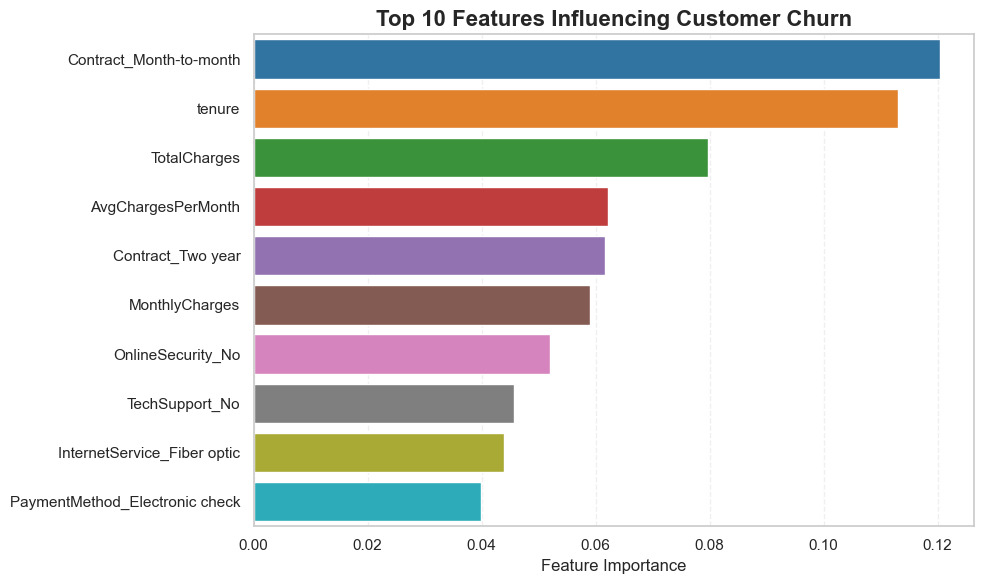

In [65]:
# Extract feature names from the preprocessing pipeline
feature_names = best_tuned_model.named_steps["preprocess"].get_feature_names_out()

# Extract feature importance from the tuned Random Forest
importance = best_tuned_model.named_steps["model"].feature_importances_

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Select Top 10 features
top10 = feature_importance.head(10).copy()

# Clean feature names
top10["Feature"] = (
    top10["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="tab10",
    legend=False
)

plt.title("Top 10 Features Influencing Customer Churn", fontsize=16, weight="bold")
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insights
- Customers with shorter tenure are more likely to churn than long-term customers.
- Customers with higher monthly charges have a greater likelihood of leaving the company.
- Customers on month-to-month contracts exhibit the highest churn rates compared to those on longer-term contracts.
- The absence of online security and technical support services is associated with increased customer churn.
- Certain payment methods, such as electronic checks (if confirmed by your visualization), show higher churn rates.
- Customers with lower total charges are generally more likely to churn, reflecting shorter customer relationships.
- The tuned Random Forest model identified these variables as the most influential factors affecting customer churn, enabling the company to target high-risk customers with proactive retention strategies.

## 11. Discussion and Reflection

### Which model performed best?
The **tuned Random Forest** is the final model: Test F1 ≈ 0.63, churn recall ≈ 0.76, AUC ≈ 0.84. Logistic Regression was essentially tied in cross-validation (CV F1 ≈ 0.634 for both) and remains an attractive, more interpretable alternative with slightly higher recall (≈ 0.78). KNN reached the highest accuracy but the lowest F1 — confirming that accuracy is the wrong headline metric for this imbalanced problem.

### Which features were most important?
Across Mutual Information and Random Forest importance, the same drivers appear: **contract type (month-to-month vs two-year), tenure, total/monthly charges, electronic-check payment, fiber-optic internet, and the absence of online security / tech support**. The engineered features contributed measurably: `AvgChargesPerMonth` ranks among the top predictors and the `TenureGroup` bins appear in both rankings.

### Did the models overfit or underfit?
Untuned, the Decision Tree overfitted severely (near-perfect training fit, Test F1 ≈ 0.48). After tuning, train–test F1 gaps are ≈ 0.02–0.03 for three models and ≈ 0.10 for the Random Forest — controlled and acceptable. No model underfits dramatically, but the overall F1 ceiling (~0.63) suggests the available features only partially explain churn.

### Main limitations
1. **Precision trade-off:** the class-weighted models flag more customers than actually churn (precision ≈ 0.50–0.54), so roughly half of a retention campaign's targets would have stayed anyway.
2. **Cross-sectional snapshot:** the dataset has no time dimension (no usage trends, complaints, or competitor offers), which likely caps predictive performance.
3. **Correlated features:** tenure, TotalCharges, TenureGroup and AvgChargesPerMonth are interrelated, so individual importance scores should be read as indicative rather than exact causal weights.
4. **Single dataset:** results are specific to this IBM sample; generalization to another telecom would require re-validation.

### Future improvements
Gradient-boosting models (XGBoost / LightGBM) typically outperform Random Forests on tabular churn data; resampling methods such as SMOTE could complement class weighting; the decision threshold could be tuned against real retention-campaign costs instead of the default 0.5; SHAP values would give customer-level explanations; and richer behavioral/temporal data would likely raise the performance ceiling.

### Conclusion
The complete workflow — cleaning, EDA, feature engineering, leakage-safe preprocessing, model comparison, GridSearchCV tuning and stratified cross-validation — produced a robust churn classifier that identifies about **three out of four at-risk customers** and clear, actionable churn drivers. The strongest business levers are moving month-to-month customers to longer contracts, bundling security/support services, and targeting early-tenure, high-charge customers with retention offers.

## 12. Roles and Contributions

Each member focused on one part of the workflow, but all members reviewed the full notebook and can explain every step.

| Member | Contribution |
|---|---|
| *Kalaivani, Jasmeet* | Dataset selection, data understanding, and preprocessing (missing values, type conversion, ID removal) |
| *Jasmeet, Kalaivani* | Statistical analysis, EDA visualizations, and outlier assessment |
| *Sreelakshmi, Aditya* | Feature engineering (TenureGroup, AvgChargesPerMonth) and feature selection (Mutual Information, feature importance) |
| *Sreelakshmi, Utkarsh* | Model training, hyperparameter tuning (GridSearchCV), and cross-validation |
| *Aditya, Utkarsh* | Evaluation, visualization, interpretation, and report/notebook organization |


## 13. References

1. IBM Sample Data Sets — Telco Customer Churn. Kaggle. https://www.kaggle.com/datasets/blastchar/telco-customer-churn
2. Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12, 2825–2830. https://scikit-learn.org
3. Scikit-learn User Guide — Cross-validation and Grid Search. https://scikit-learn.org/stable/modules/grid_search.html
4. Waskom, M. (2021). *seaborn: statistical data visualization.* JOSS 6(60), 3021.
5. Course materials — Statistics and Machine Learning, SRH University of Applied Sciences Heidelberg.